In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
pacientes = pd.read_csv("patients.csv")
agenda = pd.read_csv("appointments.csv")
medicos = pd.read_csv("doctors.csv")
tratamento = pd.read_csv("treatments.csv")
billing = pd.read_csv("billing.csv")

In [ ]:
pacientes.head()

,patient_id,first_name,last_name,gender,date_of_birth,contact_number,address,registration_date,insurance_provider,insurance_number,email
0,P001,David,Williams,F,1955-06-04,6939585183,789 Pine Rd,2022-06-23,WellnessCorp,INS840674,david.williams@mail.com
1,P002,Emily,Smith,F,1984-10-12,8228188767,321 Maple Dr,2022-01-15,PulseSecure,INS354079,emily.smith@mail.com
2,P003,Laura,Jones,M,1977-08-21,8397029847,321 Maple Dr,2022-02-07,PulseSecure,INS650929,laura.jones@mail.com
3,P004,Michael,Johnson,F,1981-02-20,9019443432,123 Elm St,2021-03-02,HealthIndia,INS789944,michael.johnson@mail.com
4,P005,David,Wilson,M,1960-06-23,7734463155,123 Elm St,2021-09-29,MedCare Plus,INS788105,david.wilson@mail.com


In [ ]:
medicos.head()

,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [ ]:
medicos = medicos.rename(columns={'first_name': 'first_name_M'})

In [ ]:
medicos.head()

,doctor_id,first_name_M,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [ ]:
medicos = medicos.rename(columns={'last_name': 'last_name_M'})

In [ ]:
medicos.head()

,doctor_id,first_name_M,last_name_M,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com


In [ ]:
agenda['appointment_date'] = pd.to_datetime(agenda['appointment_date'])

tratamento['treatment_date'] = pd.to_datetime(tratamento['treatment_date'])

billing['bill_date'] = pd.to_datetime(billing['bill_date'])

In [ ]:
## fazer junção das tabelas

df = agenda.merge(
    pacientes, on= 'patient_id',
    how='left'
)

df = df.merge(
    medicos, on= 'doctor_id',
    how='left'
)

df = df.merge(
    tratamento,on= 'appointment_id',
    how="left"
)

df = df.merge(
    billing, on='treatment_id',
    how='left'
)

In [ ]:
df.head()

,appointment_id,patient_id_x,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,...,treatment_type,description,cost,treatment_date,bill_id,patient_id_y,bill_date,amount,payment_method,payment_status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,...,Chemotherapy,Basic screening,3941.97,2023-08-09,B001,P034,2023-08-09,3941.97,Insurance,Pending
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,...,MRI,Advanced protocol,4158.44,2023-06-09,B002,P032,2023-06-09,4158.44,Insurance,Paid
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,...,MRI,Standard procedure,3731.55,2023-06-28,B003,P048,2023-06-28,3731.55,Insurance,Paid
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,...,MRI,Basic screening,4799.86,2023-09-01,B004,P025,2023-09-01,4799.86,Insurance,Failed
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,...,ECG,Standard procedure,582.05,2023-07-06,B005,P040,2023-07-06,582.05,Credit Card,Pending


In [ ]:
(df['amount'] == df['cost']).all()

np.True_

In [ ]:
df = df.drop(columns=['cost'])

In [ ]:
(df['patient_id_x'] == df['patient_id_y']).all()

np.True_

In [ ]:
df = df.drop(columns=['patient_id_y'])

In [ ]:
df.head()

,appointment_id,patient_id_x,doctor_id,appointment_date,appointment_time,reason_for_visit,status,first_name,last_name,gender,...,email_y,treatment_id,treatment_type,description,treatment_date,bill_id,bill_date,amount,payment_method,payment_status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled,Alex,Smith,F,...,dr.sarah.smith@hospital.com,T001,Chemotherapy,Basic screening,2023-08-09,B001,2023-08-09,3941.97,Insurance,Pending
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show,Alex,Moore,M,...,dr.david.jones@hospital.com,T002,MRI,Advanced protocol,2023-06-09,B002,2023-06-09,4158.44,Insurance,Paid
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled,Emily,Miller,M,...,dr.david.jones@hospital.com,T003,MRI,Standard procedure,2023-06-28,B003,2023-06-28,3731.55,Insurance,Paid
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled,Robert,Wilson,M,...,dr.alex.davis@hospital.com,T004,MRI,Basic screening,2023-09-01,B004,2023-09-01,4799.86,Insurance,Failed
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show,Emily,Williams,M,...,dr.jane.smith@hospital.com,T005,ECG,Standard procedure,2023-07-06,B005,2023-07-06,582.05,Credit Card,Pending


In [ ]:
total_pacientes = agenda['appointment_id'].nunique()
print(f'o total de pacientes é {total_pacientes}')

o total de pacientes é 200


In [ ]:
total_consultas = agenda['appointment_id'].nunique()
print(f'o total de consultas é {total_consultas}')

o total de consultas é 200


In [ ]:
receita_total = billing['amount'].sum()
print(f'a receita total é: {receita_total}')

a receita total é: 551249.8500000001


In [ ]:
ticket_medio = billing['amount'].mean()
print(f'ticket médio é {ticket_medio}')

ticket médio é 2756.2492500000003


In [ ]:
cancelamento = (agenda['status'].value_counts(normalize = True)*100
                
                
                )
print(f'A taxa de cancelamento em % {cancelamento}')

A taxa de cancelamento em % status
No-show      26.0
Scheduled    25.5
Cancelled    25.5
Completed    23.0
Name: proportion, dtype: float64


Text(0, 0.5, 'Quatidade')

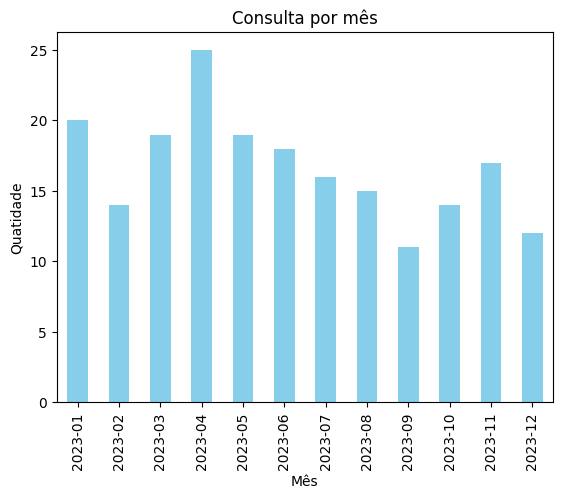

In [ ]:
agenda['mes'] = agenda['appointment_date'].dt.to_period('M')

consulta_mes = agenda.groupby('mes').size()
consulta_mes.plot.bar('Mês',"Quatidade", color='skyblue')
plt.title("Consulta por mês")
plt.xlabel("Mês")
plt.ylabel("Quatidade")

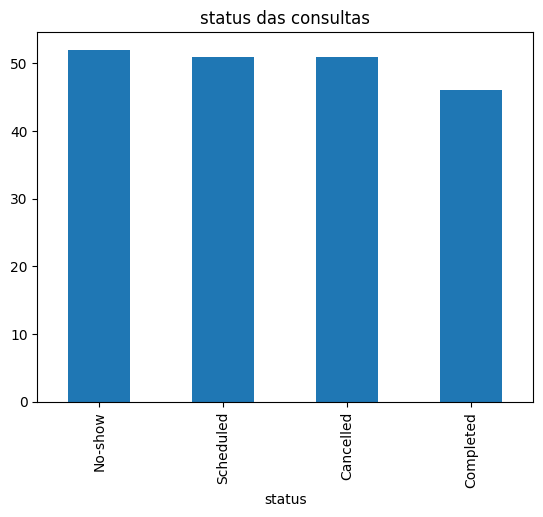

In [ ]:
agenda['status'].value_counts().plot( kind = 'bar')

plt.title('status das consultas')
plt.show()

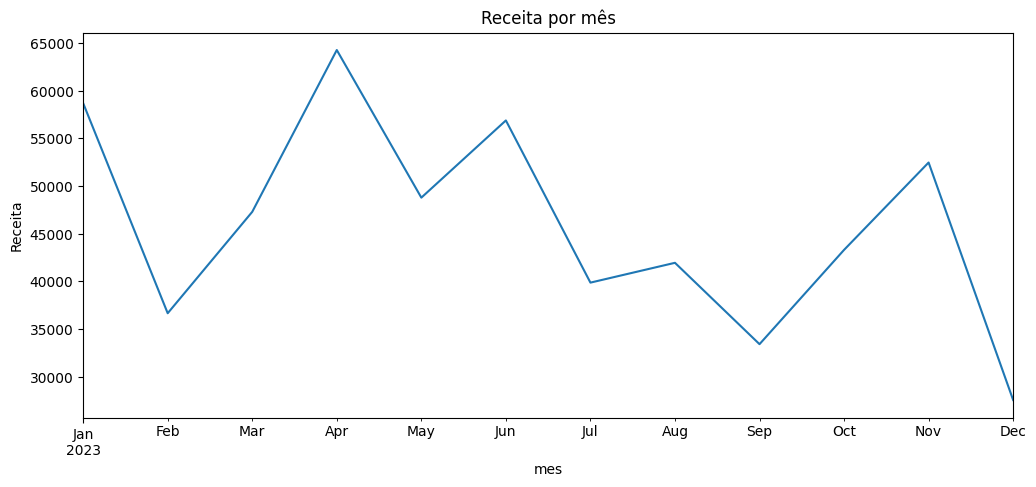

In [ ]:
billing['mes'] = billing['bill_date'].dt.to_period('M')

receita_mes = billing.groupby('mes')['amount'].sum()

receita_mes.plot(figsize=(12,5))
plt.title("Receita por mês")
plt.ylabel("Receita")
plt.show()

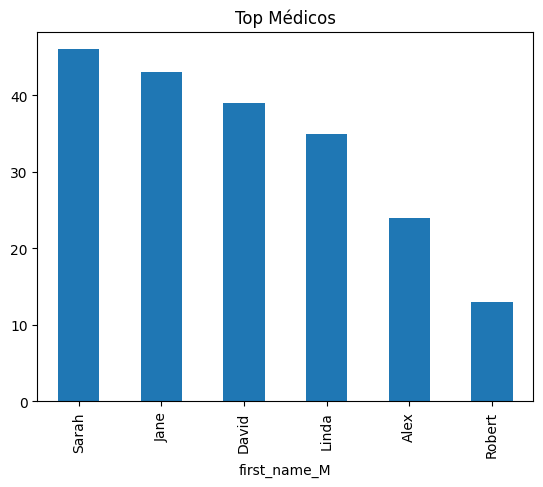

In [ ]:
top_medicos = df.groupby("first_name_M"
).size().sort_values(ascending=False).head(10)

top_medicos.plot(kind= 'bar')
plt.title('Top Médicos')
plt.show()

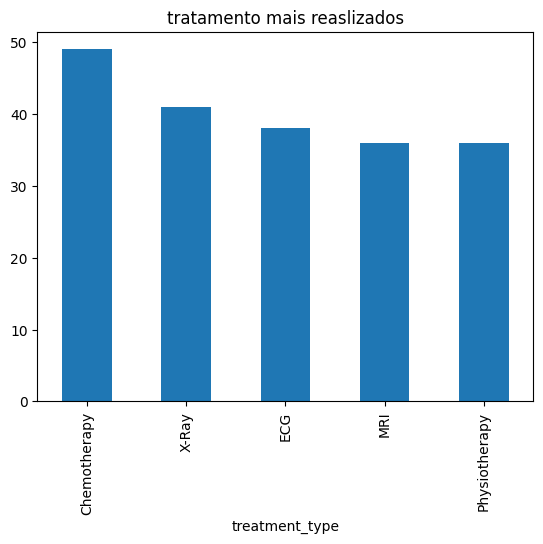

In [ ]:
tratamento['treatment_type'].value_counts().plot(
    kind= "bar"
)
plt.title("tratamento mais reaslizados")
plt.show()

In [ ]:
##status por tipo de consulta 
taxa_status = pd.crosstab(df['reason_for_visit'],
                          df['status'], normalize= 'index') *100

print((taxa_status[['Cancelled', 'No-show']].sort_values(by=['Cancelled','No-show'],
                                                         ascending= False)))

status            Cancelled    No-show
reason_for_visit                      
Consultation      34.883721  25.581395
Emergency         27.586207  34.482759
Follow-up         24.390244  14.634146
Therapy           23.809524  35.714286
Checkup           17.777778  22.222222


<Axes: xlabel='reason_for_visit'>

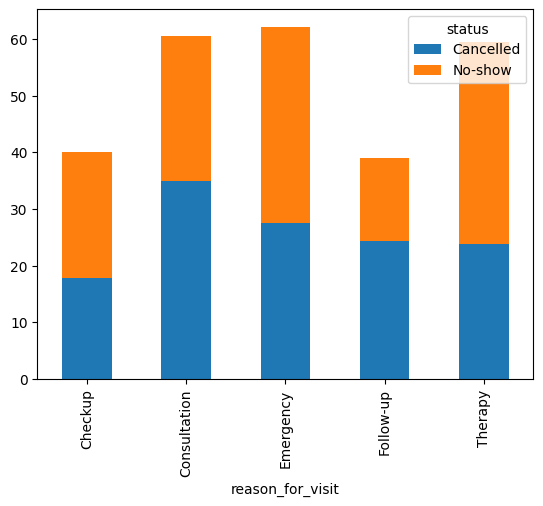

In [ ]:
taxa_status[['Cancelled', 'No-show']].plot(kind='bar', stacked= True)

In [ ]:
demand_por_especialidade = df['specialization'].value_counts().reset_index()
demand_por_especialidade.columns = ['specialization', 'total_consultas']

In [ ]:
oferta_por_especialidade = medicos['specialization'].value_counts().reset_index()
oferta_por_especialidade.columns = ['specialization', 'qtd_medicos']

In [ ]:
analise_capacidade = pd.merge(demand_por_especialidade,
                              oferta_por_especialidade,
                              on='specialization',
                              how= 'outer').fillna(0)

In [ ]:
## média de consultas que cada médico da área atende

analise_capacidade['consultas_por_medico'] = analise_capacidade['total_consultas'] / analise_capacidade['qtd_medicos']

print(analise_capacidade.sort_values(by='total_consultas',ascending=False))

  specialization  total_consultas  qtd_medicos  consultas_por_medico
2     Pediatrics               98            5             19.600000
0    Dermatology               70            3             23.333333
1       Oncology               32            2             16.000000


In [ ]:
## Relatorio de Analise
#Emergencia- Apresenta a maior taxa de no-show(não comparecimento), gastando recursos do hospital podendo atrapalhar atendimentos urgentes reais.

#Consultas - lidera em cancelamento prévios, sugerindo possivel insatisfação com prazos horarios, ou até mesmo preços

##***Recomendação***
#Implementar um sistema de confirmação via whatsapp 24h antes do prazo, para reduzir prejuizos de horas médicas ociosas

#Area de Dermatology esta apresentando maior demanda de consultas por medicos

##Recomendação
#Rever carga horaria ou contratar mais medico para area

##**Sazonalidade**
#observa-se uma queda em alguns meses do ano no numero de consultas
##Recomendação
#Campanhas Preventivas para aumentar o número de pacientes
#Progamar férias de funcionarios nos meses de menor movimento